In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_csv("data_processed_uber.csv")
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


<h2 style="color:#FF5733"> 3- Feature Engineering </h2>

In [56]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_year"] = df["pickup_datetime"].dt.year
df["pickup_month"] = df["pickup_datetime"].dt.month
df["pickup_day"] = df["pickup_datetime"].dt.day
df["pickup_day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["pickup_hour"] = df["pickup_datetime"].dt.hour

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Why these features are important?</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">

1.year: Uber pricing may change over the years due to inflation or pricing policies.
2.month: Demand varies by season and holidays.
3.day: Captures possible monthly travel patterns.
4.day_of_week: Weekends and weekdays have different demand.
5.hour:	Rush hours and nighttime trips usually have different fares.
    </ul>
</div>

<h2 style="color:green"> Determinig weekends:  </h2>

In [57]:
df["is_weekend"] = df["pickup_day_of_week"].isin([5,6]).astype(int)
#5 and 6 refer to Saturday and Sunday as they are the days of weekend

In [58]:
df[["pickup_day_of_week", "is_weekend"]].head(10)

,pickup_day_of_week,is_weekend
0,3,0
1,4,0
2,0,0
3,4,0
4,3,0
5,5,1
6,6,1
7,4,0
8,3,0
9,4,0


<h2 style="color:green"> Determinig the distance in km:  </h2>

<h2 style="color:purple"> Creating a function for Haversine method to calculate the distance in km from the longtudes and latitudes in degrees </h2>

In [59]:
def haversine_distance(lat1, lon1, lat2, lon2):
    #Earth's radius in km
    R = 6371

    #converting deg to rad
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    #calculating differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    #Haversin formula
    a = np.sin(dlat / 2) **2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


In [60]:
#apply the function
df["trip_distance_km"] = haversine_distance(df["pickup_latitude"], df["pickup_longitude"], df["dropoff_latitude"], df["dropoff_longitude"] )


<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Why using Haversine formula?</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
We used the Haversine formula because it computes the great-circle distance between two geographic coordinates on the Earth's spherical surface, providing a more accurate and easier to understand distance estimate in km.
    </ul>
</div>

<h2 style="color:purple"> Checking the distance data </h2>

In [61]:
df["trip_distance_km"].describe()

count    195019.000000
mean          3.323744
std           3.724829
min           0.000000
25%           1.256016
50%           2.156716
75%           3.906876
max         115.073410
Name: trip_distance_km, dtype: float64

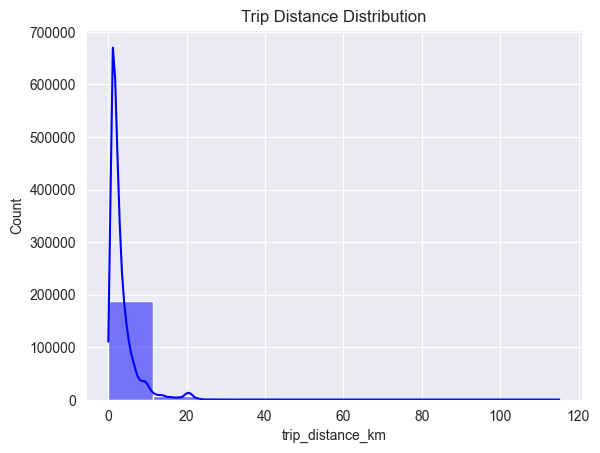

In [62]:
sns.histplot(df["trip_distance_km"], bins = 10, kde = True , color = "blue")
plt.title("Trip Distance Distribution")
plt.show()

<h2 style="color:purple"> Checking the rows of distance = 0 </h2>

In [63]:
zero_distance = df[df["trip_distance_km"] == 0]


In [64]:
normal_distance = df[df["trip_distance_km"] != 0]

In [65]:
comparison = pd.DataFrame({
    "Normal trips": normal_distance["fare_amount"].describe(),
    "Zero distance trips": zero_distance["fare_amount"].describe()
})
comparison

,Normal trips,Zero distance trips
count,192989.000000,2030.000000
mean,11.306117,10.634054
std,9.370417,12.304608
min,2.500000,2.500000
25%,6.000000,4.900000
50%,8.500000,6.500000
75%,12.500000,10.100000
max,100.000000,98.000000


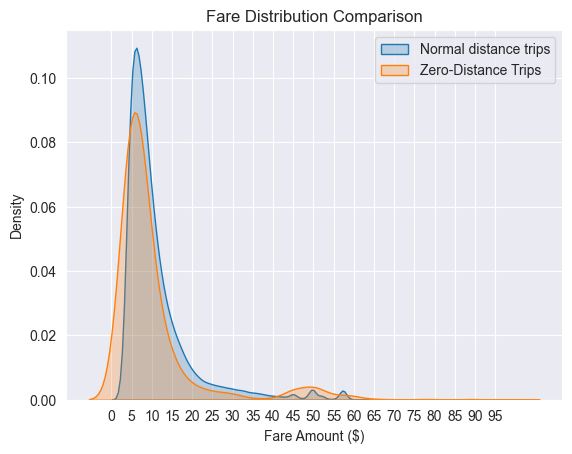

In [66]:
sns.kdeplot(normal_distance["fare_amount"], fill=True)


sns.kdeplot(zero_distance["fare_amount"],  fill=True)


plt.legend(["Normal distance trips", "Zero-Distance Trips"])
plt.title("Fare Distribution Comparison")
plt.xlabel("Fare Amount ($)")

plt.xticks(np.arange(0,100,5))

plt.show()

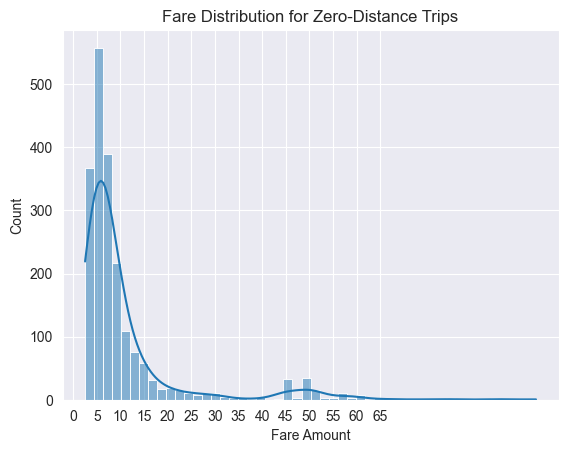

In [67]:


sns.histplot(
    zero_distance["fare_amount"],
    bins=50,
    kde=True
)

plt.title("Fare Distribution for Zero-Distance Trips")
plt.xlabel("Fare Amount")
plt.xticks(np.arange(0,70,5))
plt.show()

In [68]:
zero_distance.sort_values(
    by="fare_amount",
    ascending=False
)[[
    "fare_amount",
    "passenger_count",
    "pickup_datetime"
]].head()

,fare_amount,passenger_count,pickup_datetime
51276,98.0,1,2011-04-27 01:03:00+00:00
43494,96.0,1,2014-06-14 12:05:43+00:00
45233,90.0,2,2009-04-10 16:57:29+00:00
117422,89.0,1,2013-06-24 16:40:08+00:00
58897,88.0,1,2013-06-02 19:22:08+00:00


In [69]:
print((zero_distance['fare_amount'] <= 5).sum())
print((zero_distance['fare_amount'] > 11.4).sum())
print((zero_distance['fare_amount'] > 20).sum())
print((zero_distance['fare_amount'] > 50).sum())

619
425
201
53


In [70]:
fare_threshold = normal_distance["fare_amount"].mean()
df = df[
    ~(
    (df["trip_distance_km"] == 0 & (df["fare_amount"] > fare_threshold))
    )
]

In [71]:
df.info()

<class 'pandas.DataFrame'>
Index: 192989 entries, 0 to 195018
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   fare_amount         192989 non-null  float64            
 1   pickup_datetime     192989 non-null  datetime64[us, UTC]
 2   pickup_longitude    192989 non-null  float64            
 3   pickup_latitude     192989 non-null  float64            
 4   dropoff_longitude   192989 non-null  float64            
 5   dropoff_latitude    192989 non-null  float64            
 6   passenger_count     192989 non-null  int64              
 7   pickup_year         192989 non-null  int32              
 8   pickup_month        192989 non-null  int32              
 9   pickup_day          192989 non-null  int32              
 10  pickup_day_of_week  192989 non-null  int32              
 11  pickup_hour         192989 non-null  int32              
 12  is_weekend          192989 non-n

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Handling Zero-Distance Strategy </h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">_Compared the fare distribution of zero-distance trips with normal trips using descriptive statistics and distribution plots.
_The analysis showed that many zero-distance trips had fares comparable to regular trips, suggesting that they may represent valid minimum-fare rides or GPS inaccuracies rather than invalid observations.
_Only zero-distance trips with fares greater than the average fare of normal trips were considered inconsistent and removed, preserving potentially valid observations while eliminating suspicious records.</ul>
</div>

<h2 style="color:green"> Determinig the rush hours:  </h2>


In [72]:
hourly_trips = df.groupby("pickup_hour").size()

In [73]:
hourly_trips


pickup_hour
0      7587
1      5690
2      4266
3      3140
4      2281
5      1884
6      3995
7      6990
8      8788
9      9017
10     8666
11     9068
12     9603
13     9644
14     9448
15     9252
16     7990
17     9381
18    11642
19    12147
20    11347
21    11052
22    10648
23     9463
dtype: int64

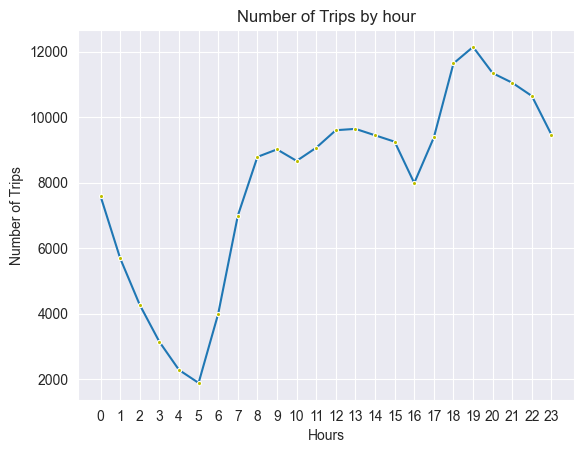

In [74]:
sns.lineplot(
    x = hourly_trips.index,
    y = hourly_trips.values,
    marker = ".",
    markerfacecolor = "y",
)

plt.xticks(range(24))
plt.xlabel("Hours")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by hour")
plt.show()

In [75]:
hourly_trips.sort_values(ascending=False)

pickup_hour
19    12147
18    11642
20    11347
21    11052
22    10648
13     9644
12     9603
23     9463
14     9448
17     9381
15     9252
11     9068
9      9017
8      8788
10     8666
16     7990
0      7587
7      6990
1      5690
2      4266
6      3995
3      3140
4      2281
5      1884
dtype: int64

In [76]:

rush_hours = [19, 18, 20, 21, 22]


In [77]:
rush_hours
#there are the ru

[19, 18, 20, 21, 22]

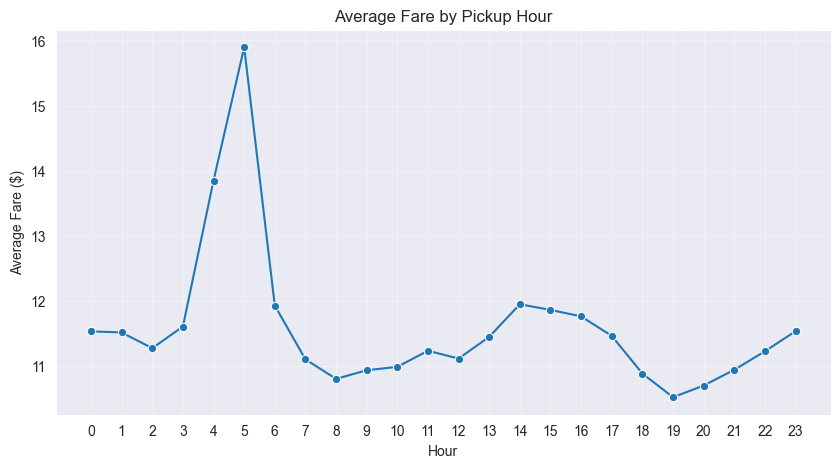

In [78]:
hourly_fare = df.groupby("pickup_hour")["fare_amount"].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_fare.index,
    y=hourly_fare.values,
    marker="o"
)

plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Average Fare ($)")
plt.title("Average Fare by Pickup Hour")

plt.grid(alpha=0.3)
plt.show()

In [79]:
df["is_rush_hour"] = df["pickup_hour"].isin(rush_hours).astype(int)

In [80]:
df.groupby("is_rush_hour")["fare_amount"].describe()


,count,mean,std,min,25%,50%,75%,max
is_rush_hour,,,,,,,,
0,136153.0,11.498186,9.722693,2.5,6.0,8.5,12.9,100.0
1,56836.0,10.846010,8.449466,2.5,6.1,8.5,12.1,100.0


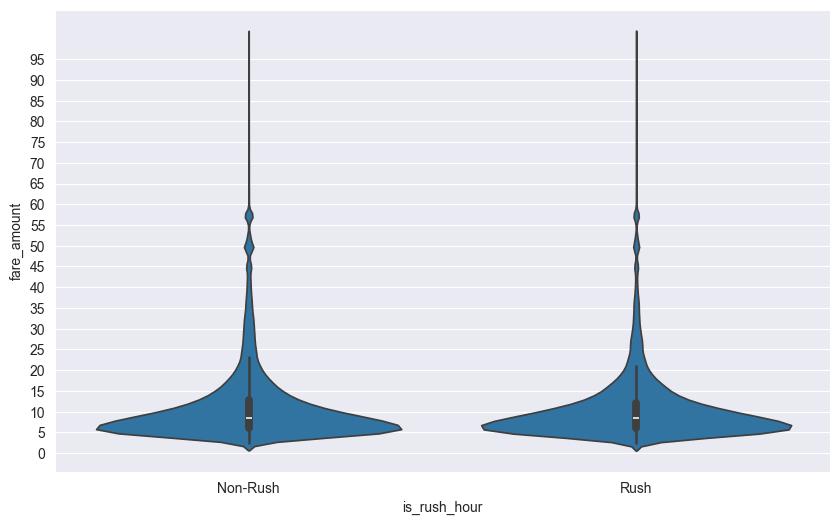

In [81]:
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x="is_rush_hour",
    y="fare_amount"
)

plt.xticks([0,1], ["Non-Rush", "Rush"])
plt.yticks(np.arange(0,100,5))

plt.show()

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Rush hours </h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
    The relationship between pickup hour and average fare was investigatedd to determine whether a rush_hour feature should be engineered. The analysis showed that there was no meaningful relationship between the rush hours and the fair amount. Therefore, the feature will be removed in the feature selection.
</ul>
</div>

<h2 style="color:green"> Distance from center NYC:  </h2>


In [82]:
center_lat = 40.7580
center_lon = -73.9855
#the position of Times square the center of Manhattan in NYC

df["pickup_to_center_km"] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    center_lat, center_lon
)

df["dropoff_to_center_km"] = haversine_distance(
    df["dropoff_latitude"],
    df["dropoff_longitude"],
    center_lat, center_lon
)

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Distance from City Center Feature</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
Used Times Square as a representative reference point for the center of New York City.</li>
        <li>Computed the Haversine distance from each pickup and dropoff location to the city center.</li>
        <li>Created two new features:
            <ul>
                <li><code>pickup_to_center_km</code></li>
                <li><code>dropoff_to_center_km</code></li>
            </ul>
        </li>
        <li>These features provide information about how centrally located each trip is, which may influence fare patterns.</li>

</ul>
</div>

<h2 style="color:green"> Bearing (Direction of the trip):  </h2>


In [83]:
  #converting deg to rad
lat1 = np.radians(df["pickup_latitude"])
lon1 = np.radians(df["pickup_longitude"])
lat2 = np.radians(df["dropoff_latitude"])
lon2 = np.radians(df["dropoff_longitude"])

    #calculating differences
dlat = lat2 - lat1
dlon = lon2 - lon1

#Bearing formula:
x = np.sin(dlon) * np.cos(lat2)
y = (np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

bearing = np.degrees(np.arctan2(x, y))

In [84]:
#Normalizing the value to become 0°-360° instead of -180°-180°
df["bearing"] = (bearing + 360) * 360

In [89]:
df.to_csv("data_engineered_uber.csv", index=False)